# MyLumi: the models, in the open

This notebook runs **the same code that serves the app**, on **the same data the
demo shows**, so that every number in the product can be checked rather than
taken on trust.

Nothing here is a reimplementation. Each section imports the real module from
`backend/app/models/` and calls it the way the API does. If a model refuses to
answer, that refusal appears below instead of being edited out, because refusing
is most of what these models are for.

The models, and what each one is for:

| Module | Method | Question it answers |
|---|---|---|
| `correlation.py` | Spearman rank correlation, threshold search, Holm-Bonferroni | Which of my habits track my symptoms? |
| `forecast.py` | Ridge regression, closed form | How heavy is tomorrow likely to be? |
| `validation.py` | Walk-forward backtest, split-conformal interval | Is any of this better than guessing? |
| `state.py` | Kalman filter with an RTS smoother | Which way am I actually going? |
| `symptoms.py` | Theil-Sen slopes, Kendall tau, Holm-Bonferroni | Which symptoms are easing, and which are not? |
| `anomaly.py` | Median and MAD | Was yesterday genuinely unusual? |

Every model is fit per request on one person's data and then discarded. There is
no training set, no population model, and no stored weights: a user's own
history is the entire training corpus, which is why the sample sizes here are
tens of rows rather than thousands, and why refusing to speak matters so much.

In [1]:
import sys
from pathlib import Path

# The backend package and the ported demo generator.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "notebooks"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# The real models. Nothing below reimplements any of this.
from app.models import anomaly, confidence, correlation, features, forecast, state, symptoms, validation
from demo_seed import build_demo_nights, to_feature_rows, SYMPTOM_KEYS

# MyLumi's palette, so the charts read as part of the same product.
PURPLE, MAGENTA = "#4C1D95", "#D6249F"
WARM, MUTED, GRID = "#FFB265", "#B9AED6", "#3B2A6B"
INK = "#F4F1FB"

plt.rcParams.update({
    "figure.facecolor": "#140A2E", "axes.facecolor": "#1E1240",
    "savefig.facecolor": "#140A2E",
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.alpha": 0.45,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "600",
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.linewidth": 0.6,
})
print("numpy", np.__version__)

numpy 2.2.1


## 1. The data

24 nights from `frontend/src/lib/demoSeed.js`, ported to Python in
`demo_seed.py`. The port is exact: the JS uses a specific 32-bit PRNG
(mulberry32) seeded at 20260214, so `demo_seed.py` reproduces that generator and
the order of every draw from it, including draws for values this notebook never
reads. All 24 nights were compared field by field against the JS output.

Two things about this data matter more than its realism.

**The sleep effect is planted in the inputs, never in the outputs.** The
generator makes six nights short and lets short sleep raise the *following*
day's symptoms. It does not write a correlation, a p-value, or a finding. The
correlation engine in section 2 has to discover the effect the same way it would
on a real person's data, and it is allowed to fail.

**Two nights are missing on purpose.** A record where every night is logged
would hide the handling that most of this code is about. Those gaps stay gaps:
they are never interpolated, and they cost the models real training pairs.

In [2]:
nights = build_demo_nights()
rows = to_feature_rows(nights)
episodes = features.to_episodes(rows)

print(f"nights generated : 24")
print(f"nights logged    : {len(nights)}  (2 deliberate gaps)")
print(f"complete episodes: {features.complete_count(episodes)}")
print(f"confidence tier  : {confidence.tier_for(features.complete_count(episodes))}")

day = np.array([n.day_index for n in nights])
burden = np.array([n.symptom_burden for n in nights])
sleep = np.array([n.sleep_hours for n in nights])

nights generated : 24
nights logged    : 22  (2 deliberate gaps)
complete episodes: 22
confidence tier  : good


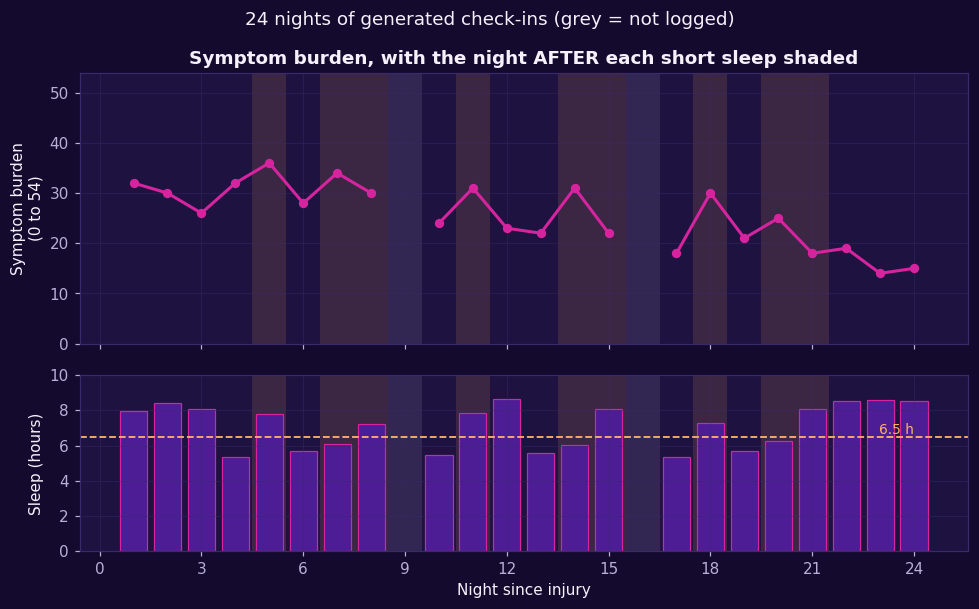

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1.3]})

# Gaps drawn as gaps. Consecutive runs only, so no line is drawn across a night
# nobody logged - the same rule the app's charts follow.
runs, run = [], [0]
for i in range(1, len(day)):
    if day[i] == day[i - 1] + 1:
        run.append(i)
    else:
        runs.append(run)
        run = [i]
runs.append(run)

for r in runs:
    ax1.plot(day[r], burden[r], color=MAGENTA, lw=2, zorder=3)
ax1.scatter(day, burden, color=MAGENTA, s=26, zorder=4)

short = sleep < 6.5
for d in day[short]:
    for ax in (ax1, ax2):
        ax.axvspan(d + 0.5, d + 1.5, color=WARM, alpha=0.13, lw=0, zorder=0)

missing = sorted(set(range(1, 25)) - set(day.tolist()))
for d in missing:
    for ax in (ax1, ax2):
        ax.axvspan(d - 0.5, d + 0.5, color=MUTED, alpha=0.13, lw=0, zorder=0)

ax1.set_ylabel("Symptom burden\n(0 to 54)")
ax1.set_title("Symptom burden, with the night AFTER each short sleep shaded")
ax1.set_ylim(0, 54)

ax2.bar(day, sleep, color=PURPLE, edgecolor=MAGENTA, lw=0.8)
ax2.axhline(6.5, color=WARM, ls="--", lw=1.2)
ax2.text(day.max(), 6.68, "6.5 h", color=WARM, ha="right", fontsize=9)
ax2.set_ylabel("Sleep (hours)")
ax2.set_xlabel("Night since injury")
ax2.set_ylim(0, 10)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.suptitle("24 nights of generated check-ins (grey = not logged)", y=0.98)
fig.tight_layout()
plt.show()

The shading marks the day *after* a short night, which is where the planted
effect should land. Whether it is actually detectable is the next section's
problem, not the generator's.

## 2. Correlation: finding the effect, and refusing to over-find

`correlation.py` tests seven candidate features against symptom burden using
**Spearman rank correlation**, which is chosen over Pearson deliberately: it
responds to monotonic relationships without assuming a straight line, and a
handful of rough nights cannot drag it the way they would drag a Pearson
coefficient.

Testing seven things at p < 0.05 is where naive analysis goes wrong. A large
share of pure-noise datasets will hand you at least one "significant" finding
once you look at enough features - the cell after next measures exactly how
large on this setup. So the module applies a **Holm-Bonferroni** step-down
correction: sort the p-values, and require the i-th smallest to beat
alpha / (m - i). It is uniformly more powerful than plain Bonferroni and makes
no independence assumption, which matters here because sleep quality and sleep
duration are obviously not independent.

The module also refuses to use causal language anywhere. A backend test asserts
that the words "causes", "because of" and "due to" never appear in a statement,
because a correlation on 22 nights of one person's self-reports cannot support
them.

In [4]:
result = correlation.correlate(episodes)
print("available :", result["available"], "| confidence:", result.get("confidence"))
print()
for f in result.get("findings") or []:
    print(f"  {f['statement']}")
    print(f"    rho = {f['rho']}   p = {f['pValue']}   n = {f['n']} pairs")
    if f.get("thresholdStatement"):
        print(f"    {f['thresholdStatement']}")
    print()

available :

 True | confidence: good

  Your symptom burden tends to be strongly higher on days following more average pain rating.
    rho = 0.67   p = 0.0024   n = 18 pairs
    On days following over 5.0 of average pain rating, your symptom burden runs about 13 points higher.

  Your symptom burden tends to be strongly higher on days following more worst pain rating.
    rho = 0.67   p = 0.0026   n = 18 pairs
    On days following over 5.1 of worst pain rating, your symptom burden runs about 10 points higher.

  Your symptom burden tends to be strongly higher on days following less sleep duration.
    rho = -0.62   p = 0.0046   n = 19 pairs
    On days following under 8.1 hours of sleep duration, your symptom burden runs about 11 points higher.



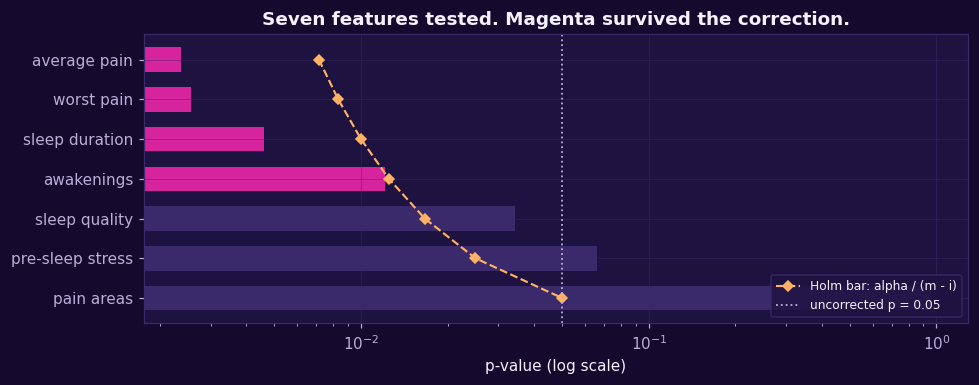

5 of 7 would pass at an uncorrected p < 0.05
4 survive Holm-Bonferroni


In [5]:
# The correction, made visible: every candidate tested, against the bar it had
# to clear. The bar is what changes per rank, not the p-value.
from scipy import stats

CANDIDATES = ["sleepDurationHours", "sleepQuality", "awakenings", "preSleepStress",
              "painRegionCount", "painMax", "painMean"]
LABELS = {"sleepDurationHours": "sleep duration", "sleepQuality": "sleep quality",
          "awakenings": "awakenings", "preSleepStress": "pre-sleep stress",
          "painRegionCount": "pain areas", "painMax": "worst pain", "painMean": "average pain"}

tested = []
for feat in CANDIDATES:
    x, y = features.paired_series(episodes, feat)
    if len(x) >= correlation.MIN_PAIRS:
        rho, p = stats.spearmanr(x, y)
        if np.isfinite(rho) and np.isfinite(p):
            tested.append((LABELS[feat], float(rho), float(p)))

tested.sort(key=lambda t: t[2])
m = len(tested)
bars = [correlation.ALPHA / (m - i) for i in range(m)]

fig, ax = plt.subplots(figsize=(9, 3.6))
names = [t[0] for t in tested]
ps = [t[2] for t in tested]
ypos = np.arange(m)

survives, broken = [], False
for i, p in enumerate(ps):
    ok = (not broken) and p <= bars[i]
    if not ok:
        broken = True
    survives.append(ok)

ax.barh(ypos, ps, color=[MAGENTA if s else GRID for s in survives], height=0.62)
ax.plot(bars, ypos, color=WARM, marker="D", ms=5, ls="--", lw=1.4,
        label="Holm bar: alpha / (m - i)")
ax.axvline(0.05, color=MUTED, ls=":", lw=1.2, label="uncorrected p = 0.05")
ax.set_yticks(ypos, names)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("p-value (log scale)")
ax.set_title("Seven features tested. Magenta survived the correction.")
ax.legend(loc="lower right", fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)
fig.tight_layout()
plt.show()

print(f"{sum(1 for p in ps if p <= 0.05)} of {m} would pass at an uncorrected p < 0.05")
print(f"{sum(survives)} survive Holm-Bonferroni")

That the correction removed something here is not the argument, though. The
argument is what it does to data with **no signal in it at all**, which is
measurable directly: generate pure noise, run the same test, and count how often
it produces a confident finding.

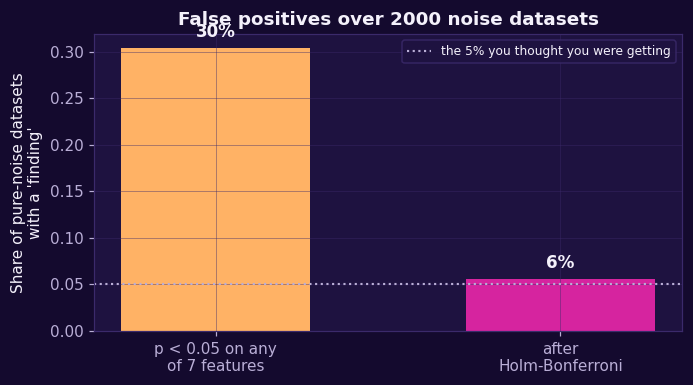

Testing 7 features at p < 0.05 finds something in 30% of
datasets that contain nothing. Holm-Bonferroni brings that to 6%.
That is the difference between a tool that finds patterns and one that
manufactures them.


In [6]:
# The false-positive rate, measured rather than quoted. Pure noise, no effect
# planted, the same seven-feature test.
rng = np.random.default_rng(20260214)
TRIALS = 2000
n_obs, n_features = 20, 7

naive_hits = corrected_hits = 0
for _ in range(TRIALS):
    y_noise = rng.normal(size=n_obs)
    pvals = sorted(
        float(stats.spearmanr(rng.normal(size=n_obs), y_noise)[1])
        for _ in range(n_features)
    )
    if pvals[0] <= 0.05:
        naive_hits += 1
    # Holm: the i-th smallest must beat alpha / (m - i), stopping at the first failure.
    for i, p in enumerate(pvals):
        if p > correlation.ALPHA / (n_features - i):
            break
        corrected_hits += 1
        break

fig, ax = plt.subplots(figsize=(6.4, 3.6))
vals = [naive_hits / TRIALS, corrected_hits / TRIALS]
bars = ax.bar(["p < 0.05 on any\nof 7 features", "after\nHolm-Bonferroni"], vals,
              color=[WARM, MAGENTA], width=0.55)
ax.axhline(0.05, color=MUTED, ls=":", lw=1.4, label="the 5% you thought you were getting")
ax.set_ylabel("Share of pure-noise datasets\nwith a 'finding'")
ax.set_title(f"False positives over {TRIALS} noise datasets")
ax.legend(fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.0%}",
            ha="center", color=INK, fontsize=11, fontweight="600")
fig.tight_layout()
plt.show()

print(f"Testing 7 features at p < 0.05 finds something in {naive_hits / TRIALS:.0%} of")
print(f"datasets that contain nothing. Holm-Bonferroni brings that to "
      f"{corrected_hits / TRIALS:.0%}.")
print("That is the difference between a tool that finds patterns and one that")
print("manufactures them.")

The engine found the planted sleep relationship without being told it was there,
which is the only result that would have meant anything.

The pain features rank alongside it, and that is worth being honest about rather
than hiding: the generator couples pain ratings to symptom burden on the same
night, so a correlation between them is real in this data and the engine is
right to report it. It is also the *less* interesting finding, because same-day
pain and same-day symptoms are close to measuring the same thing. The sleep
finding is the one that carries information, because it is lagged: last night's
sleep against today's symptoms.

Note the wording throughout: "on days following less sleep", never "caused by".
A rank correlation on 19 pairs of one person's self-reports cannot support a
causal claim, and the model is not permitted to make one.

## 3. Forecast: ridge regression, and what it leans on

`forecast.py` fits **ridge regression in closed form**, solving

$$\hat{\beta} = (X^\top X + \alpha I)^{-1} X^\top y$$

with alpha = 1.0 on standardized features. There is no scikit-learn here, and no
gradient descent: at these sample sizes the normal equations are a 5x5 solve
that runs in microseconds, and writing it out means the regularization is
visible rather than a constructor argument.

Ridge rather than ordinary least squares because the features are collinear by
nature - sleep duration, sleep quality and awakenings all measure the same
night - and OLS on 20-odd rows with correlated predictors produces large,
unstable, sign-flipping coefficients. The alpha penalty trades a little bias for
much less variance.

The model also **adapts its own feature count**: `ROWS_PER_FEATURE = 2.5` means
features are dropped when there is not enough history to fit them, rather than
fitting five parameters through eight points and reporting the result with a
straight face.

In [7]:
result = forecast.forecast(episodes)
print("available:", result["available"], "| confidence:", result.get("confidence"))
print(f"predicted burden tomorrow: {result['predictedBurden']}  "
      f"interval {result['interval']}  (scale 0 to {forecast.MAX_BURDEN})")
print()
print("what the prediction leaned on, by |coefficient x standardized value|:")
for d in result.get("drivers") or []:
    print(f"  {d['label']:<28} weight {d['weight']}  ({d['direction']})")

available: True | confidence: moderate
predicted burden tomorrow: 13.6  interval [6.7, 20.6]  (scale 0 to 54)

what the prediction leaned on, by |coefficient x standardized value|:
  pre-sleep stress             weight 5.81  (decreases)
  night-time awakenings        weight 2.54  (decreases)
  today's symptom burden       weight 1.99  (decreases)


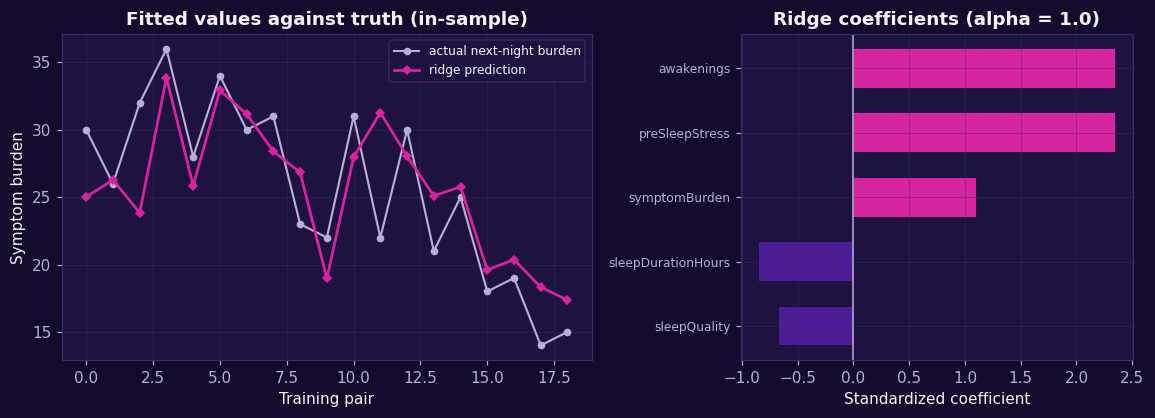

Positive: more of this feature goes with a heavier next day.
These are standardized, so their sizes are comparable to each other.


In [8]:
# Fit the same model the endpoint fits, and score every night in-sample so the
# predictions can be seen against the truth. Out-of-sample scoring is section 4.
names, x, y, _ = forecast._select_features(episodes)
coefs, y_mean, mu, sigma = forecast._fit_ridge(x, y)
pred = y_mean + ((x - mu) / sigma) @ coefs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9),
                               gridspec_kw={"width_ratios": [1.35, 1]})

ax1.plot(y, color=MUTED, marker="o", ms=4, lw=1.4, label="actual next-night burden")
ax1.plot(pred, color=MAGENTA, marker="D", ms=4, lw=1.8, label="ridge prediction")
ax1.set_xlabel("Training pair")
ax1.set_ylabel("Symptom burden")
ax1.set_title("Fitted values against truth (in-sample)")
ax1.legend(fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)

order = np.argsort(np.abs(coefs))
ax2.barh(np.arange(len(coefs)), coefs[order],
         color=[MAGENTA if c > 0 else PURPLE for c in coefs[order]], height=0.6)
ax2.set_yticks(np.arange(len(coefs)), [names[i] for i in order], fontsize=8)
ax2.axvline(0, color=MUTED, lw=1)
ax2.set_xlabel("Standardized coefficient")
ax2.set_title(f"Ridge coefficients (alpha = {forecast.RIDGE_ALPHA})")

fig.tight_layout()
plt.show()

print("Positive: more of this feature goes with a heavier next day.")
print("These are standardized, so their sizes are comparable to each other.")

## 4. Calibration: the part that caught the model lying

This is the most important section in the notebook, and it is the one that shows
a failure.

An 80% prediction interval makes a checkable promise: the truth should fall
inside it about 80% of the time. The first version of MyLumi's forecast built
its interval by multiplying the in-sample residual spread by 1.28, the normal
z-score for 80%. It advertised 80% coverage.

Backtesting it found the real figure was about **51%**. The interval was barely
better than a coin toss while being labelled as an 80% interval, because
in-sample residuals systematically understate the error a model makes on data it
has not seen.

The fix, in `validation.py`, is a **walk-forward backtest** feeding a
**split-conformal interval**. To score night t the model is refit on nights
0..t-1 only, so every error is genuinely out-of-sample. The interval half-width
is then a quantile of those real errors, with the finite-sample correction
`ceil((n + 1) * 0.8)`, rather than a number derived from a normal assumption
nobody checked.

The same errors produce both the interval and the reported coverage, so the
number shown to the user and the interval they see cannot disagree.

The 51% figure comes from the project's own testing across many generated
histories. The cell below measures this particular 22-night record, where the
sample is small enough that the exact numbers will differ - the comparison
between the two methods is the point, not the specific percentage.

In [9]:
wf = validation.walk_forward(episodes)
report = validation.validate(episodes)
half = validation.conformal_half_width(episodes)

print(f"folds scored          : {report['folds']}  (expanding window, one step ahead)")
print(f"model mean abs error  : {report['modelError']} burden points")
print(f"naive 'same as today' : {report['naiveError']} burden points")
print(f"skill score           : {report['skillScore']}  (beats naive: {report['beatsNaive']})")
print()
print(f"conformal half-width  : {half:.2f} burden points")
print(f"measured coverage     : {report['coverage']} against a target of {report['targetCoverage']}")
print()
print(report["statement"])

folds scored          : 13  (expanding window, one step ahead)
model mean abs error  : 4.92 burden points
naive 'same as today' : 5.92 burden points
skill score           : 0.17  (beats naive: True)

conformal half-width  : 8.05 burden points
measured coverage     : 0.923 against a target of 0.8

Tested on 13 of your own nights, MyLumi's forecast was about 17% closer than simply assuming tomorrow matches today.


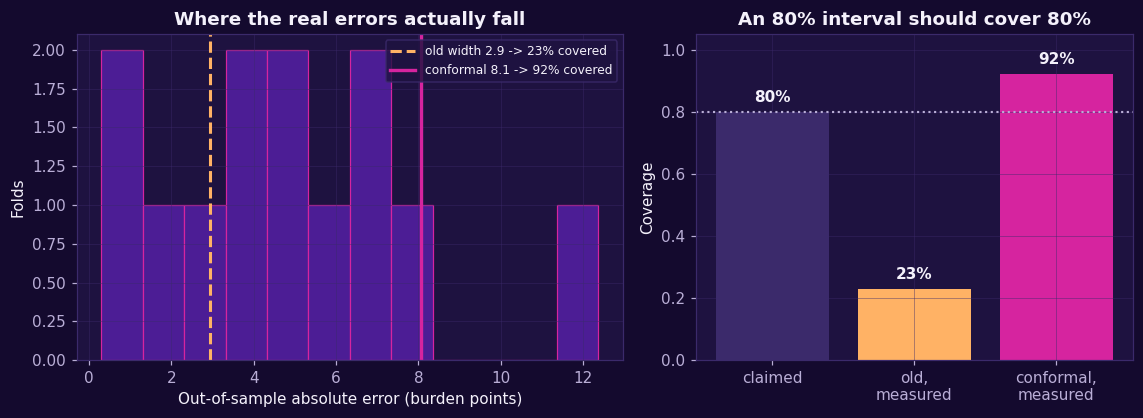

In [10]:
errors = np.abs(np.asarray(wf["errors"], dtype=float))

# The old approach, rebuilt exactly as it was: in-sample residual spread times
# the tier multiplier for a 'good' history.
names_f, x_f, y_f, _ = forecast._select_features(episodes)
coefs_f, ymean_f, mu_f, sigma_f = forecast._fit_ridge(x_f, y_f)
in_sample = np.abs(y_f - (ymean_f + ((x_f - mu_f) / sigma_f) @ coefs_f))
old_half = float(np.std(in_sample)) * confidence.widening_for("good")

old_cov = float(np.mean(errors <= old_half))
new_cov = float(np.mean(errors <= half))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9),
                               gridspec_kw={"width_ratios": [1.25, 1]})

ax1.hist(errors, bins=12, color=PURPLE, edgecolor=MAGENTA, lw=0.8)
ax1.axvline(old_half, color=WARM, ls="--", lw=2,
            label=f"old width {old_half:.1f} -> {old_cov:.0%} covered")
ax1.axvline(half, color=MAGENTA, lw=2.2,
            label=f"conformal {half:.1f} -> {new_cov:.0%} covered")
ax1.set_xlabel("Out-of-sample absolute error (burden points)")
ax1.set_ylabel("Folds")
ax1.set_title("Where the real errors actually fall")
ax1.legend(fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)

bars = ax2.bar(["claimed", "old,\nmeasured", "conformal,\nmeasured"],
               [validation.TARGET_COVERAGE, old_cov, new_cov],
               color=[GRID, WARM, MAGENTA])
ax2.axhline(validation.TARGET_COVERAGE, color=MUTED, ls=":", lw=1.4)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Coverage")
ax2.set_title("An 80% interval should cover 80%")
for b, v in zip(bars, [validation.TARGET_COVERAGE, old_cov, new_cov]):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.0%}",
             ha="center", color=INK, fontsize=10, fontweight="600")

fig.tight_layout()
plt.show()

The gap between the first two bars is the whole argument for building a
validation layer that is allowed to return bad news. A model that can only
confirm itself is decoration.

`validate()` also compares the model against "tomorrow will be like today". That
baseline is harder to beat than it sounds, and if the personal model does not
beat it, the app says so.

## 5. Recovery state: a Kalman filter over noisy self-reports

A daily symptom score is a noisy measurement of something that moves slowly.
Asking "am I improving?" by comparing today to yesterday mostly measures the
noise.

`state.py` treats it as a **linear Gaussian state-space model** with a hidden
state of level and slope:

$$x_t = \begin{bmatrix} \text{level} \\ \text{slope} \end{bmatrix}, \quad
F = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}, \quad
H = \begin{bmatrix} 1 & 0 \end{bmatrix}$$

A forward **Kalman filter** pass gives the best estimate at each night from data
up to that night; a backward **RTS smoother** pass revises each night using
everything that came after, which is the right question for a journal, where all
the data already exists.

Two decisions here are worth more than the filter itself:

**The noise ratio is a fixed clinical prior, not fitted by EM.** Expectation-
maximization over 10 to 40 points collapsed the process noise and produced
estimates worse than the raw self-reports in two trials out of three. The fixed
ratio beat raw self-reports in 24 trials out of 24. At this sample size,
estimating the noise is overfitting it.

**Gaps widen the interval instead of inventing a reading.** `dt` grows across a
missed night, so the covariance grows with it. The filter's uncertainty is
allowed to say "I do not know what happened here."

In [11]:
result = state.recovery_state(episodes)
print("available:", result["available"], "| confidence:", result.get("confidence"))
print(f"slope: {result['slopePerDay']} burden points per day  -> {result['direction']}")
print(f"observation noise (sd): {result.get('observationNoise')}")
print()
print(result.get("statement"))

available: True | confidence: moderate
slope: -0.892 burden points per day  -> improving
observation noise (sd): 3.0

Underneath the day-to-day movement, your symptom burden has been easing by roughly 6.2 points a week. Individual nights vary by about 3 points around that line.


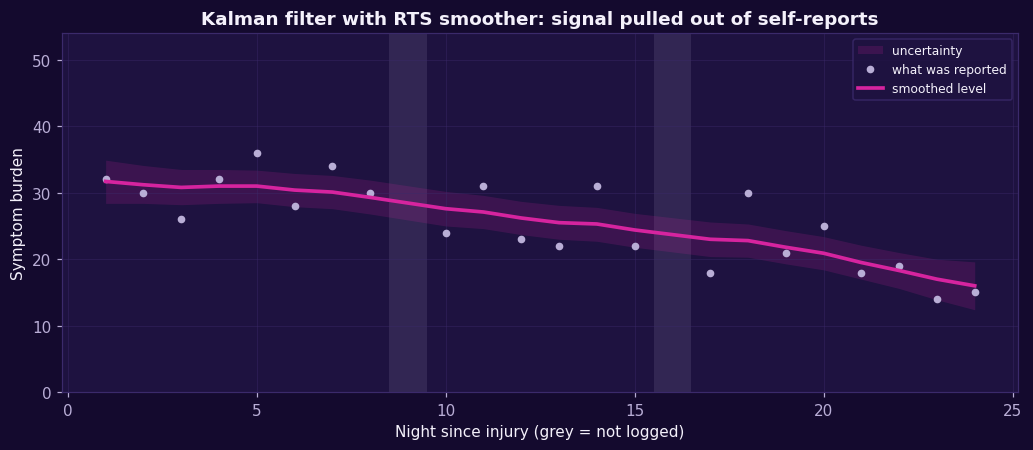

interval width: narrowest 4.9, widest 7.2 burden points
The band is widest where nights are missing and at the ends of the series,
which is exactly where the model knows least.


In [12]:
pts = result["points"]

# Points come back keyed by date; map each back to its night index so the gaps
# show as gaps on the x axis rather than being closed up.
night_index = {n.night_of: n.day_index for n in nights}
idx = np.array([night_index[p["nightOf"]] for p in pts], dtype=float)
obs = np.array([p["observed"] for p in pts], dtype=float)
lvl = np.array([p["level"] for p in pts], dtype=float)
lo = np.array([p["lower"] for p in pts], dtype=float)
hi = np.array([p["upper"] for p in pts], dtype=float)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.fill_between(idx, lo, hi, color=MAGENTA, alpha=0.16, lw=0, label="uncertainty")
ax.plot(idx, obs, color=MUTED, marker="o", ms=4, lw=0, label="what was reported")
ax.plot(idx, lvl, color=MAGENTA, lw=2.4, label="smoothed level")

for d in sorted(set(range(1, 25)) - set(int(i) for i in idx)):
    ax.axvspan(d - 0.5, d + 0.5, color=MUTED, alpha=0.13, lw=0, zorder=0)

ax.set_xlabel("Night since injury (grey = not logged)")
ax.set_ylabel("Symptom burden")
ax.set_title("Kalman filter with RTS smoother: signal pulled out of self-reports")
ax.legend(fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)
ax.set_ylim(0, 54)
fig.tight_layout()
plt.show()

width = hi - lo
print(f"interval width: narrowest {width.min():.1f}, widest {width.max():.1f} burden points")
print("The band is widest where nights are missing and at the ends of the series,")
print("which is exactly where the model knows least.")

The direction is only named when the slope clears two separate bars: a minimum
effect size, and 1.96 standard deviations of the slope estimate. A trend too
small or too uncertain to distinguish from flat is reported as unclear rather
than as good news.

## 6. Per-symptom trends: Theil-Sen, and nine chances to be wrong

Aggregate burden hides the interesting question. Headache can be improving while
concentration is not, and the sum can stay flat while both move.

`symptoms.py` fits a **Theil-Sen estimator** to each of the nine symptoms
separately: the median of the slopes between all pairs of points. Least squares
would be the obvious choice and the wrong one, because it has a breakdown point
of zero - a single terrible day drags the line. Theil-Sen tolerates up to about
29% of the data being outliers, and one awful week in a recovery record is
normal.

Significance comes from **Kendall's tau**, a rank test that makes no assumption
about the shape of the trend. Nine symptoms means nine chances for a false
positive, so Holm-Bonferroni applies again. A symptom is reported as easing or
worsening only if it survives the correction *and* its confidence interval
excludes zero *and* the weekly rate clears a minimum size. Otherwise it is
"unclear", which on this data is most of them.

In [13]:
rates = symptoms.recovery_rates(episodes)
print(f"  {'symptom':<26} {'per week':>10}   {'95% interval':<18} status")
print("  " + "-" * 68)
for r in sorted(rates, key=lambda r: r.get("weeklyChange") or 0.0):
    change = r.get("weeklyChange")
    shown = f"{change:+.2f}" if change is not None else "n/a"
    ci = (f"[{r['ciLow']:+.2f}, {r['ciHigh']:+.2f}]"
          if r.get("ciLow") is not None else "-")
    print(f"  {r['label']:<26} {shown:>10}   {ci:<18} {r['status']}")

  symptom                      per week   95% interval       status
  --------------------------------------------------------------------
  fatigue                         -0.78   [-1.24, +0.00]     easing
  headache                        -0.64   [-0.88, +0.00]     easing
  light sensitivity               -0.64   [-0.88, -0.37]     easing
  brain fog                       -0.54   [-1.08, +0.00]     unclear
  trouble concentrating           -0.44   [-0.88, +0.00]     easing
  noise sensitivity               -0.37   [-0.58, +0.00]     easing
  nausea                          +0.00   [+0.00, +0.00]     unclear
  dizziness                       +0.00   [-0.54, +0.00]     unclear
  irritability or low mood        +0.00   [-0.44, +0.00]     unclear


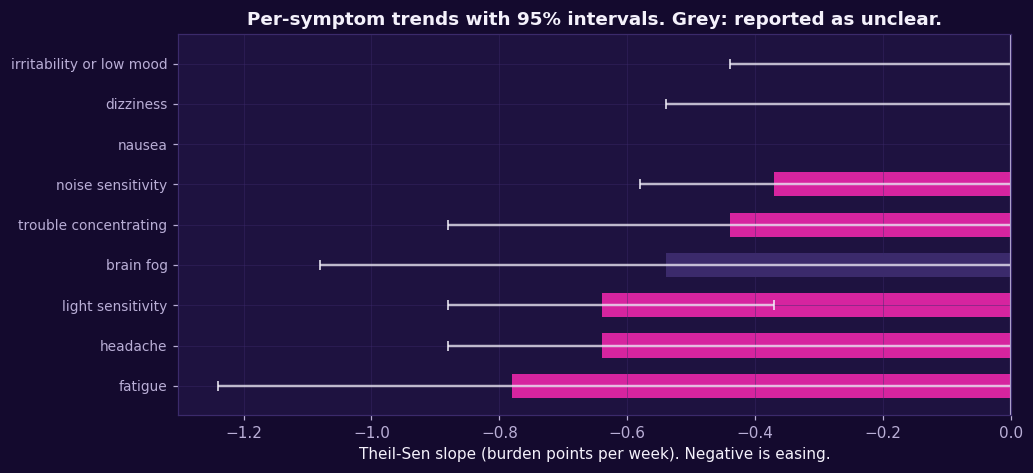

5 of 9 symptoms got a direction; 4 are reported as unclear.

  'brain fog' is unclear at -0.54/week, even though trouble concentrating was
  reported as easing on a SMALLER estimate. The point estimate is not what
  decides it: significance after correction, and an interval clear of zero, are.


In [14]:
ordered = sorted(rates, key=lambda r: r.get("weeklyChange") or 0.0)
labels = [r["label"] for r in ordered]
weekly = np.array([r.get("weeklyChange") or 0.0 for r in ordered])
lo_ci = np.array([r.get("ciLow") if r.get("ciLow") is not None else 0.0 for r in ordered])
hi_ci = np.array([r.get("ciHigh") if r.get("ciHigh") is not None else 0.0 for r in ordered])
decided = [r["status"] != "unclear" for r in ordered]
ypos = np.arange(len(ordered))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.barh(ypos, weekly, color=[MAGENTA if d else GRID for d in decided], height=0.6)

# The interval is what decides the verdict: one that straddles zero cannot claim
# a direction, however large the point estimate looks.
ax.hlines(ypos, lo_ci, hi_ci, color=INK, lw=1.6, alpha=0.75)
ax.plot(lo_ci, ypos, "|", color=INK, ms=7)
ax.plot(hi_ci, ypos, "|", color=INK, ms=7)

ax.set_yticks(ypos, labels, fontsize=9)
ax.axvline(0, color=MUTED, lw=1.4)
ax.set_xlabel("Theil-Sen slope (burden points per week). Negative is easing.")
ax.set_title("Per-symptom trends with 95% intervals. Grey: reported as unclear.")
fig.tight_layout()
plt.show()

print(f"{sum(decided)} of {len(rates)} symptoms got a direction; "
      f"{len(rates) - sum(decided)} are reported as unclear.")
print()

# The interesting cases are where the point estimate alone would have misled.
for r in ordered:
    if r["status"] != "unclear":
        continue
    change = r.get("weeklyChange")
    if change is None:
        continue
    bigger = [o["label"] for o in ordered
              if o["status"] != "unclear" and (o.get("weeklyChange") or 0) > change]
    if bigger:
        print(f"  '{r['label']}' is unclear at {change:+.2f}/week, even though "
              f"{bigger[0]} was")
        print(f"  reported as easing on a SMALLER estimate. The point estimate is not what")
        print(f"  decides it: significance after correction, and an interval clear of zero, are.")
        break

## 7. Anomaly detection: why the mean is the wrong tool

Flagging an unusual day looks like a job for a z-score: how many standard
deviations from the mean? The problem is that both the mean and the standard
deviation are computed *from the data being screened*, and a genuinely bad day
inflates both. The outlier hides itself, and drags its neighbours toward the
threshold with it.

`anomaly.py` uses the **median** and the **median absolute deviation** instead,
scaled by 1.4826 so that MAD estimates the same quantity as the standard
deviation for normally distributed data. The median has a breakdown point of
50%: half the data would have to be corrupt before it moves.

The threshold is 2.5 robust deviations, which is deliberately conservative. The
app would rather miss a marginal day than tell someone in recovery that a normal
day was a setback. And the wording never says "setback" or "relapse" - an
unusual day is "worth noting", because the model can see a number and not a
person.

In [15]:
result = anomaly.detect(episodes)
print("available:", result["available"], "| flagged:", len(result.get("anomalies") or []))
for a in result.get("anomalies") or []:
    print(f"  {a.get('nightOf')}: burden {a.get('value')}, score {a.get('score')}")
if not (result.get("anomalies") or []):
    print("  Nothing flagged. On a smooth recovery that is the correct answer.")

available: True | flagged: 0
  Nothing flagged. On a smooth recovery that is the correct answer.


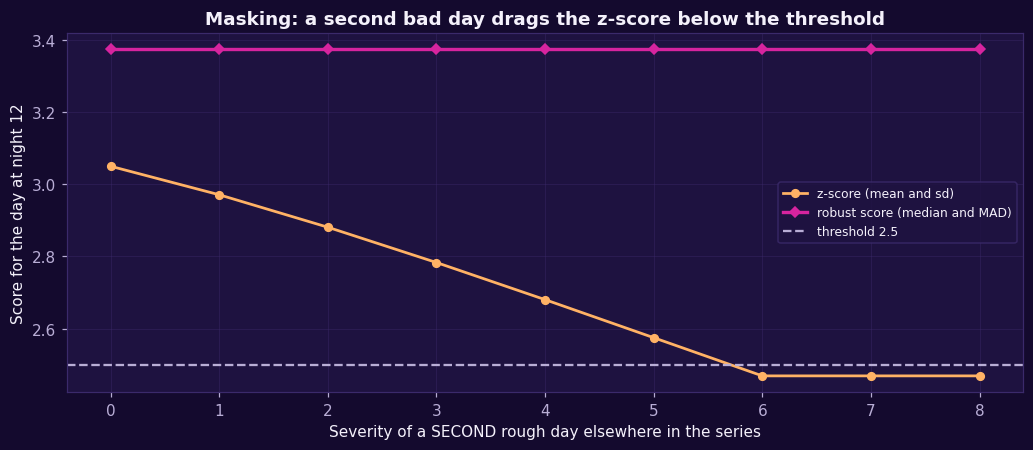

z-score:      3.05 with one outlier -> 2.47 once a second is present
robust score: 3.37 with one outlier -> 3.37 once a second is present

The z-score drops below the threshold and MISSES the day entirely once the
second rough day reaches +18 burden points. The robust score never does:
the spikes inflate the standard deviation they are measured against, while
the median barely moves.


In [16]:
# Masking, measured rather than asserted. One bad day is planted at night 12 and
# a SECOND is added at growing size, which is the situation that separates the
# two estimators: a lone outlier is easy, but a second one inflates the standard
# deviation enough to hide the first.
def scores(series, i):
    series = np.asarray(series, dtype=float)
    med = np.median(series)
    mad = np.median(np.abs(series - med)) * anomaly.MAD_TO_SIGMA
    robust = abs((series[i] - med) / mad) if mad > 0 else np.inf
    classic = abs((series[i] - series.mean()) / series.std())
    return classic, robust

sizes = np.arange(0, 9)
classic_curve, robust_curve = [], []
for extra in sizes:
    s = burden.astype(float).copy()
    s[11] = 52.0                     # the day we want flagged
    s[4] = min(54.0, s[4] + extra * 3)  # a second rough day, growing
    c, r = scores(s, 11)
    classic_curve.append(c)
    robust_curve.append(r)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(sizes, classic_curve, color=WARM, marker="o", ms=5, lw=1.8,
        label="z-score (mean and sd)")
ax.plot(sizes, robust_curve, color=MAGENTA, marker="D", ms=5, lw=2.2,
        label="robust score (median and MAD)")
ax.axhline(anomaly.THRESHOLD, color=MUTED, ls="--", lw=1.5,
           label=f"threshold {anomaly.THRESHOLD}")
ax.set_xlabel("Severity of a SECOND rough day elsewhere in the series")
ax.set_ylabel("Score for the day at night 12")
ax.set_title("Masking: a second bad day drags the z-score below the threshold")
ax.legend(fontsize=8, facecolor="#1E1240", edgecolor=GRID, labelcolor=INK)
fig.tight_layout()
plt.show()

lost = [i for i, c in enumerate(classic_curve) if c < anomaly.THRESHOLD]
print(f"z-score:      {classic_curve[0]:.2f} with one outlier -> "
      f"{classic_curve[-1]:.2f} once a second is present")
print(f"robust score: {robust_curve[0]:.2f} with one outlier -> "
      f"{robust_curve[-1]:.2f} once a second is present")
print()
if lost:
    print(f"The z-score drops below the threshold and MISSES the day entirely once the")
    print(f"second rough day reaches +{lost[0] * 3} burden points. The robust score never does:")
    print("the spikes inflate the standard deviation they are measured against, while")
    print("the median barely moves.")
else:
    print("Both still flag it here, but note the z-score falls as the second day grows")
    print("while the robust score holds: that downward slope is the masking effect.")

## 8. The refusals

Everything above assumed enough data. The behaviour that matters more is what
happens when there is not enough, because that is where a model is most tempted
to produce something that looks authoritative.

MyLumi emits **no forecast at all** under 7 complete nights. Not a wider
interval, not a hedged sentence: nothing. A prediction from 4 nights renders
identically to one from 40, and the user has no way to tell them apart, so the
only safe answer is silence.

In [17]:
print(f"{'nights':>6}  {'tier':<9}  forecast")
print("-" * 46)
for n in (3, 5, 6, 7, 10, 14, 21, 22):
    subset = episodes[:n]
    out = forecast.forecast(subset)
    verdict = (f"{out['predictedBurden']} {out['interval']}" if out["available"]
               else f"refused: {out.get('reason')}")
    print(f"{n:>6}  {confidence.tier_for(n):<9}  {verdict}")

nights  tier       forecast
----------------------------------------------
     3  none       refused: 4 more complete nights and MyLumi can start looking for patterns.
     5  none       refused: 2 more complete nights and MyLumi can start looking for patterns.
     6  none       refused: One more complete night and MyLumi can start looking for patterns.
     7  low        31.7 [27.4, 36.0]
    10  low        28.0 [20.9, 35.1]
    14  moderate   26.0 [17.1, 34.9]
    21  good       17.4 [10.4, 24.3]
    22  good       13.6 [6.7, 20.6]


The threshold is not a tuning parameter. It is the same constant in three
places: `MIN_FOR_ANY_INSIGHT` in `backend/app/models/confidence.py`,
`MIN_NIGHTS_FOR_INSIGHT` in `frontend/src/lib/constants.js`, and the number on
the About page. Changing the model's willingness to speak means changing what
the product promises.

---

### What this notebook was for

Every figure above came from the code that serves the app, on the data the demo
shows. The models are small on purpose: one person's history is the entire
training set, which is why so much of the work went into knowing when not to
answer.

The single result worth keeping is section 4. A model that claimed 80% coverage
and delivered 51% was caught by its own backtest and replaced. That is the
difference between a model that is trustworthy and one that merely sounds
confident, and it is only visible because the validation layer was built to be
able to return bad news.